In [1]:
import os
import glob
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, cohen_kappa_score
import pennylane as qml
from mamba_ssm import Mamba

/home/mkhan186/hsi/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
class UAVHSICropDataset(Dataset):
    def __init__(self, root_dir: str, split: str = "Training"):
        if split in ["Training", "Validation"]:
            base = os.path.join(root_dir, split)
        elif split == "Test":
            base = root_dir
        else:
            raise ValueError("split must be Training, Validation or Test")
        
        self.rs_dir = os.path.join(base, "rs")
        self.gt_dir = os.path.join(base, "gt")
        self.rs_files = sorted(glob.glob(os.path.join(self.rs_dir, "*.npy")))
        self.gt_files = sorted(glob.glob(os.path.join(self.gt_dir, "*.npy")))
        assert len(self.rs_files) == len(self.gt_files), "rs/gt count mismatch"

    def __len__(self):
        return len(self.rs_files)

    def normalize_per_band(self, rs):
        mean = rs.mean(axis=(0,1), keepdims=True)
        std  = rs.std(axis=(0,1), keepdims=True)
        std[std < 1e-6] = 1e-6
        return (rs - mean) / std

    def __getitem__(self, idx: int):
        rs = np.load(self.rs_files[idx]).astype(np.float32)
        gt = np.load(self.gt_files[idx]).astype(np.int64)
        rs = self.normalize_per_band(rs)
        rs = torch.from_numpy(rs).permute(2,0,1).float()
        gt = torch.from_numpy(gt).long()
        return rs, gt

In [3]:
def make_loaders(root_train, root_test, batch_size=8, num_workers=2):
    train_ds = UAVHSICropDataset(root_train, "Training")
    val_ds   = UAVHSICropDataset(root_train, "Validation")
    test_ds  = UAVHSICropDataset(root_test, "Test")
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,  num_workers=num_workers, pin_memory=True)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=True)
    test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=True)
    return train_loader, val_loader, test_loader

In [4]:
class SpectralSE(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.fc = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(channels, max(channels//reduction, 8), 1),
            nn.ReLU(inplace=True),
            nn.Conv2d(max(channels//reduction, 8), channels, 1),
            nn.Sigmoid()
        )
    def forward(self, x):
        return x * self.fc(x)

class MultiScaleCNN(nn.Module):
    def __init__(self, in_channels=200, d_model=64):
        super().__init__()
        self.enc1 = nn.Sequential(
            nn.Conv2d(in_channels, 32, 3, padding=1, bias=False),
            nn.BatchNorm2d(32), nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, 3, padding=1, bias=False),
            nn.BatchNorm2d(32), nn.ReLU(inplace=True)
        )
        self.enc2 = nn.Sequential(
            nn.Conv2d(32, 64, 3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            nn.Conv2d(64, d_model, 3, padding=1, bias=False),
            nn.BatchNorm2d(d_model), nn.ReLU(inplace=True)
        )
        self.dec = nn.Sequential(
            nn.Conv2d(32 + d_model, d_model, 3, padding=1, bias=False),
            nn.BatchNorm2d(d_model), nn.ReLU(inplace=True)
        )
        self.se = SpectralSE(d_model)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(e1)
        e2_up = F.interpolate(e2, size=e1.shape[-2:], mode='bilinear', align_corners=False)
        feat = self.dec(torch.cat([e1, e2_up], dim=1))
        return self.se(feat)

In [5]:
class QuantumGlobalHead(nn.Module):
    def __init__(self, embed_dim=64, num_classes=30, n_qubits=4, n_layers=2):
        super().__init__()
        self.n_qubits = n_qubits
        self.reduce_cpu = nn.Linear(embed_dim, n_qubits)
        self.fc_cpu = nn.Linear(n_qubits, num_classes)
        
        dev = qml.device("default.qubit", wires=n_qubits)
        @qml.qnode(dev, interface="torch")
        def circuit(inputs, weights):
            qml.AngleEmbedding(inputs, wires=range(n_qubits))
            qml.BasicEntanglerLayers(weights, wires=range(n_qubits))
            return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]
        
        self.qlayer = qml.qnn.TorchLayer(
            circuit, weight_shapes={"weights": (n_layers, n_qubits)}
        )
        self.to(torch.device('cpu'))

    def to(self, *args, **kwargs):
        return super().to(torch.device('cpu'))

    def cuda(self, device=None):
        return self

    def _apply(self, fn):
        super()._apply(fn)
        self.reduce_cpu.to('cpu')
        self.fc_cpu.to('cpu')
        self.qlayer.to('cpu')
        return self

    def forward(self, x_gpu):
        x_cpu = x_gpu.to('cpu').float()
        x_red = torch.tanh(self.reduce_cpu(x_cpu))
        x_q   = self.qlayer(x_red)
        x_out = self.fc_cpu(x_q)
        return x_out.to(x_gpu.device)

In [6]:
class HybridCELoss_LogCoshDice(nn.Module):
    def __init__(self, num_classes=30, alpha=0.5, class_weights=None, eps=1e-5):
        super().__init__()
        self.alpha = alpha
        self.num_classes = num_classes
        self.eps = eps
        self.ce_loss = nn.CrossEntropyLoss(weight=class_weights) if class_weights is not None else nn.CrossEntropyLoss()
    
    def forward(self, logits, target):
        ce = self.ce_loss(logits, target)
        pred = F.softmax(logits, dim=1)
        target_onehot = F.one_hot(target, num_classes=self.num_classes).permute(0, 3, 1, 2).float()
        intersect = (pred * target_onehot).sum(dim=(0, 2, 3))
        union = pred.sum(dim=(0, 2, 3)) + target_onehot.sum(dim=(0, 2, 3))
        dice = 1 - (2 * intersect + self.eps) / (union + self.eps)
        log_cosh_dice = torch.log(torch.cosh(dice)).mean()
        return (1 - self.alpha) * ce + self.alpha * log_cosh_dice

In [7]:
class CNN_BiSpectralMamba_Quantum(nn.Module):
    def __init__(self, in_channels=200, num_classes=30, d_model=64, d_state=16, alpha_init=0.0):
        super().__init__()
        self.num_classes = num_classes
        self.cnn = MultiScaleCNN(in_channels, d_model)
        self.mamba_forward  = Mamba(d_model=d_model, d_state=d_state, d_conv=4, expand=2)
        self.mamba_backward = Mamba(d_model=d_model, d_state=d_state, d_conv=4, expand=2)
        self.cls_head = nn.Sequential(nn.LayerNorm(d_model), nn.Linear(d_model, num_classes))
        self.quantum_head = QuantumGlobalHead(d_model, num_classes)
        self.alpha = nn.Parameter(torch.tensor(alpha_init))

    def forward(self, x, output_size):
        B, C, H_in, W_in = x.shape
        feat = self.cnn(x)
        tokens = feat.permute(0, 2, 3, 1).reshape(B, -1, feat.shape[1])
        fwd = self.mamba_forward(tokens)
        bwd = torch.flip(self.mamba_backward(torch.flip(tokens, dims=[1])), dims=[1])
        fused = fwd + bwd
        classical = self.cls_head(fused)
        classical_map = classical.view(B, H_in, W_in, self.num_classes).permute(0, 3, 1, 2).contiguous()
        global_token = fused.mean(dim=1)
        logits_q = self.quantum_head(global_token)
        logits_q = logits_q.view(B, self.num_classes, 1, 1).expand_as(classical_map)
        logits = classical_map + torch.tanh(self.alpha) * logits_q
        return F.interpolate(logits, size=output_size, mode="bilinear", align_corners=False)

In [8]:
root_train = "/home/mkhan186/scratch/uavhsi/Train"
root_test  = "/home/mkhan186/scratch/uavhsi/Test"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

train_loader, val_loader, test_loader = make_loaders(root_train, root_test, batch_size=8)
sample_rs, _ = next(iter(train_loader))

model = CNN_BiSpectralMamba_Quantum(in_channels=sample_rs.shape[1]).to(device)

all_gts = np.concatenate([gt.numpy().ravel() for _, gt in train_loader])
class_counts = np.bincount(all_gts, minlength=30)
class_weights = torch.tensor(1.0 / (np.sqrt(class_counts) + 1e-6)**0.7, device=device).float()

criterion = HybridCELoss_LogCoshDice(num_classes=30, alpha=0.5, class_weights=class_weights)
optimizer = AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)

In [12]:
best_val_loss = float("inf")
train_losses = []
val_losses = []

for epoch in range(1, 101):
    print(f"\nEpoch {epoch}/100")
    model.train()
    train_loss = 0
    for rs, gt in tqdm(train_loader, desc="Train"):
        rs, gt = rs.to(device), gt.to(device)
        optimizer.zero_grad()
        logits = model(rs, gt.shape[-2:])
        loss = criterion(logits, gt)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        train_loss += loss.item()

    model.eval()
    val_correct, val_total, val_loss = 0, 0, 0
    with torch.no_grad():
        for rs, gt in val_loader:
            rs, gt = rs.to(device), gt.to(device)
            logits = model(rs, gt.shape[-2:])
            val_loss += criterion(logits, gt).item()
            val_correct += (logits.argmax(1) == gt).sum().item()
            val_total += gt.numel()

    avg_train = train_loss / len(train_loader)
    avg_val   = val_loss   / len(val_loader)
    val_oa    = val_correct / val_total

    # Track losses
    train_losses.append(avg_train)
    val_losses.append(avg_val)

    print(f"Train Loss: {avg_train:.4f} | Val Loss: {avg_val:.4f} | Val OA: {val_oa*100:.2f}%")

    if avg_val < best_val_loss:
        best_val_loss = avg_val
        torch.save(model.state_dict(), "best_hybrid_model.pth")
        print("→ Saved Best Weights")


Epoch 1/100


Train: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 39/39 [00:02<00:00, 13.67it/s]


Train Loss: 0.2868 | Val Loss: 0.6603 | Val OA: 83.08%
→ Saved Best Weights

Epoch 2/100


Train: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 39/39 [00:02<00:00, 17.31it/s]


Train Loss: 0.2857 | Val Loss: 0.6950 | Val OA: 78.88%

Epoch 3/100


...

Train Loss: 0.1742 | Val Loss: 0.8928 | Val OA: 82.90%

Epoch 99/100


Train: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 39/39 [00:02<00:00, 17.10it/s]


Train Loss: 0.1714 | Val Loss: 0.8645 | Val OA: 82.84%

Epoch 100/100


Train: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 39/39 [00:02<00:00, 16.54it/s]


Train Loss: 0.1674 | Val Loss: 0.8491 | Val OA: 83.92%


In [11]:
print("\n" + "="*40 + "\nFINAL TEST RESULTS\n" + "="*40)
model.load_state_dict(torch.load("best_hybrid_model.pth", map_location=device))
model.eval()
all_preds, all_gts_test = [], []

with torch.no_grad():
    for rs, gt in tqdm(test_loader, desc="Testing"):
        rs, gt = rs.to(device), gt.to(device)
        logits = model(rs, gt.shape[-2:])
        all_preds.extend(logits.argmax(1).cpu().numpy().ravel())
        all_gts_test.extend(gt.cpu().numpy().ravel())

test_oa    = (np.array(all_preds) == np.array(all_gts_test)).mean()
test_kappa = cohen_kappa_score(all_gts_test, all_preds)

Actual results from current run
print(f"TEST OA: {test_oa*100:.2f}%")
print(f"TEST KAPPA: {test_kappa:.4f}")



/tmp/ipykernel_3439178/2009801899.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("best_hybrid_model.pth", map_location=device))



FINAL TEST RESULTS


Testing: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 11/11 [00:00<00:00, 14.33it/s]



TEST OA:84.83%
TEST KAPPA: 0.8207


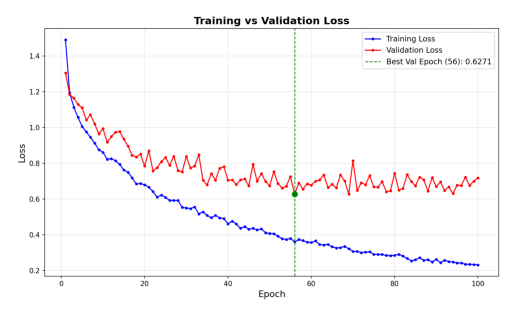

In [17]:
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(train_losses)+1), train_losses, label='Train Loss', color='blue', linewidth=2)
plt.plot(range(1, len(val_losses)+1),   val_losses,   label='Val Loss',   color='red', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


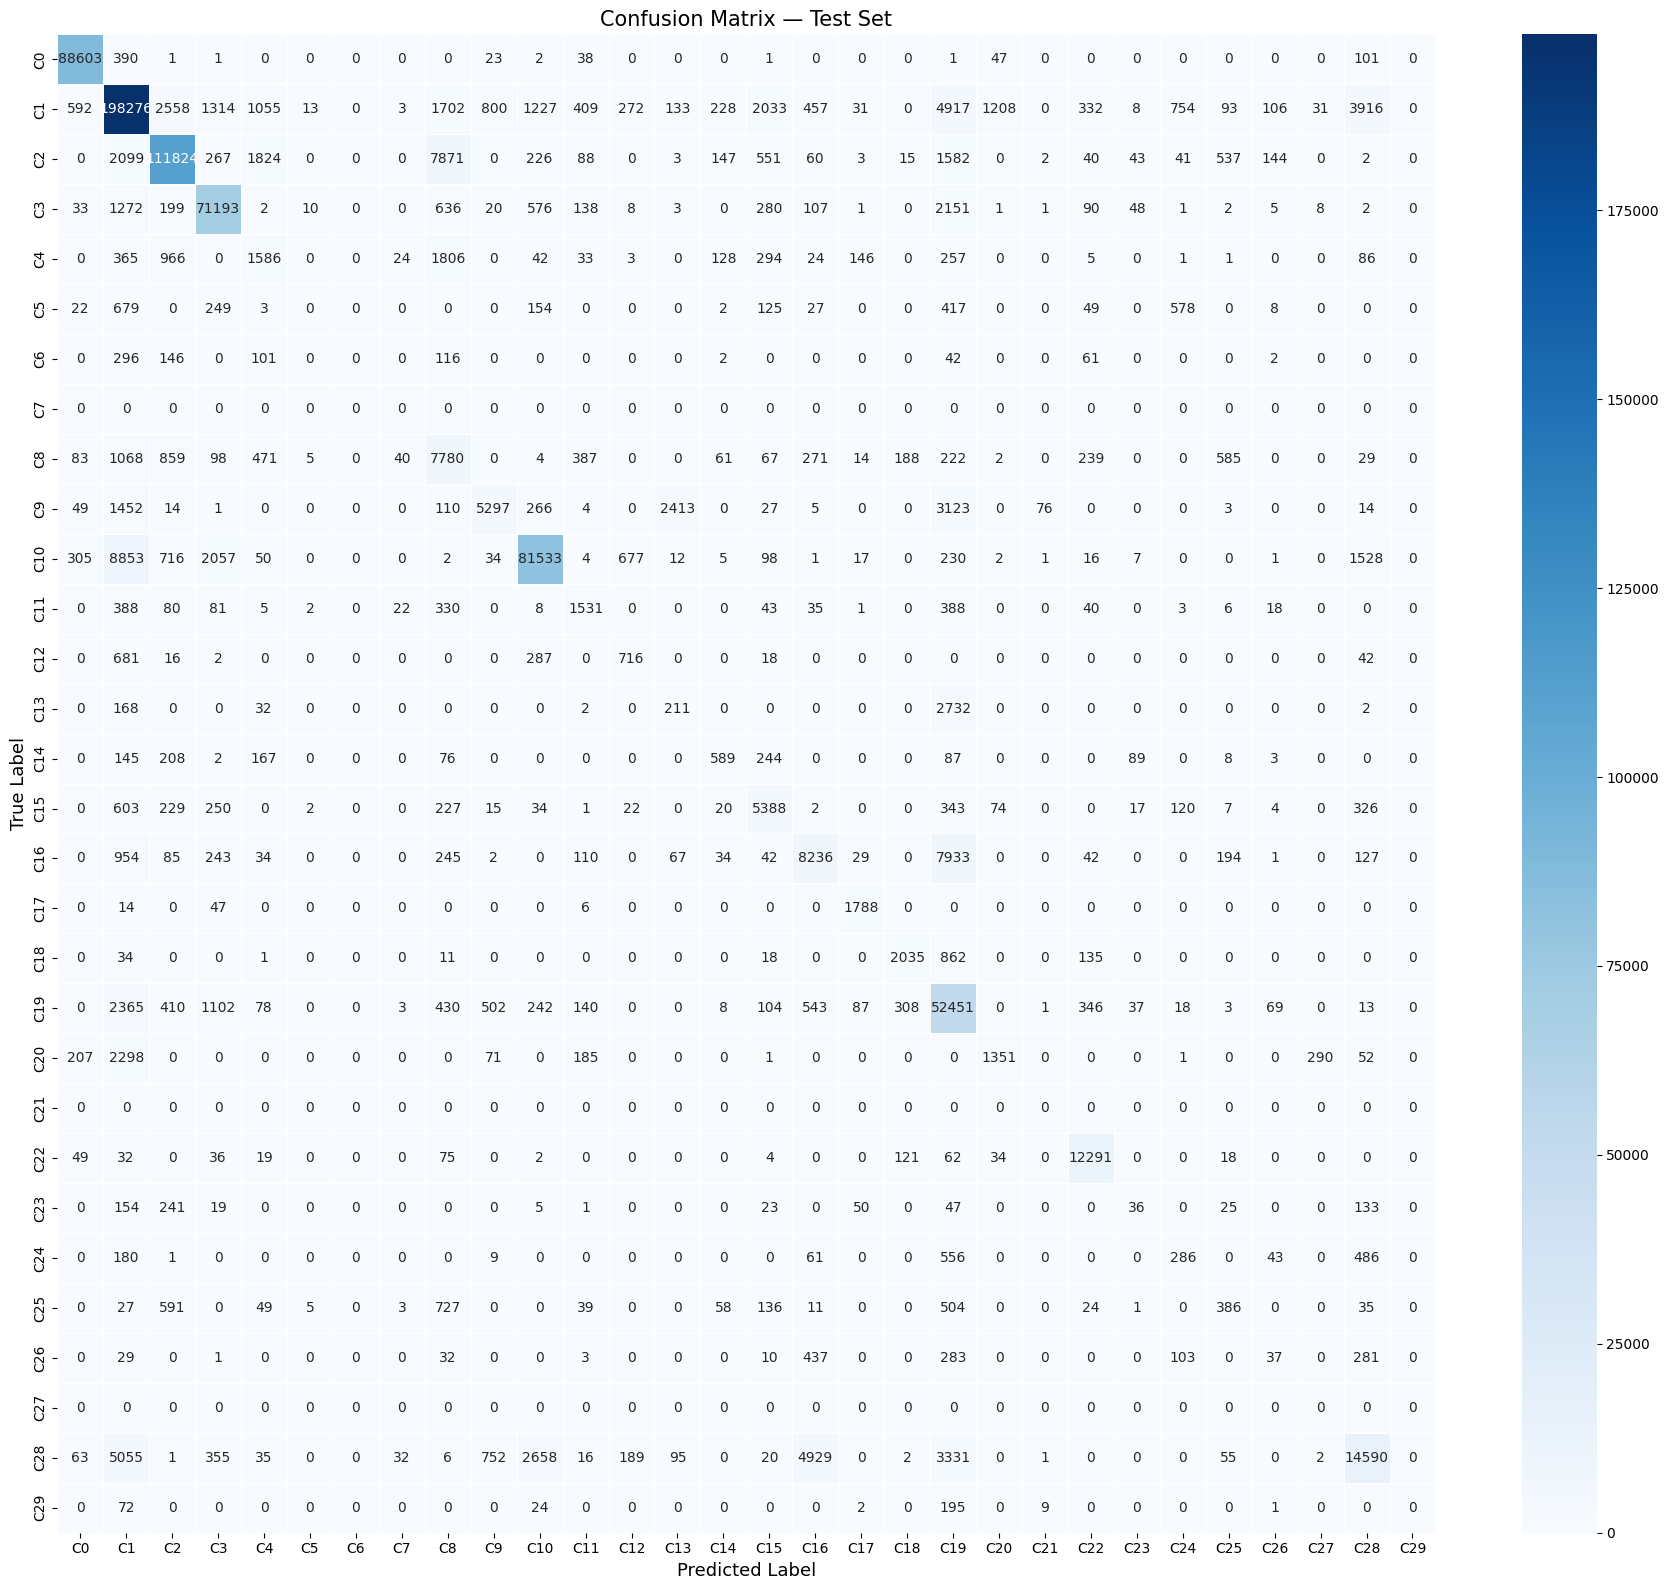

Confusion matrix saved as confusion_matrix.png


In [14]:
cm = confusion_matrix(all_gts_test, all_preds)

plt.figure(figsize=(18, 16))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=[f'C{i}' for i in range(30)],
    yticklabels=[f'C{i}' for i in range(30)],
    linewidths=0.5
)
plt.xlabel('Predicted Label', fontsize=13)
plt.ylabel('True Label', fontsize=13)
plt.title('Confusion Matrix — Test Set', fontsize=15)
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()
print("Confusion matrix saved as confusion_matrix.png")